# FGVC-Aircraft Dataset Analysis

This notebook downloads and inspects the FGVC-Aircraft dataset used in the knowledge distillation experiments. It shows dataset sizes, classes, class balance, image shapes, and example images.

## Setup

Run this notebook from the project root. If dependencies are missing, install the project first with:

```bash
.venv/bin/pip install -e .
```

In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torchvision import datasets, transforms

DATA_ROOT = Path("../data") if Path.cwd().name == "notebooks" else Path("data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
torch.manual_seed(42)

DATA_ROOT.resolve()

PosixPath('/home/zeneto/projects/mo434-dl-knowledge-distillation/data')

## Download and Load Splits

In [2]:
display_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_ds = datasets.FGVCAircraft(
    root=str(DATA_ROOT), split="train", annotation_level="variant", transform=display_transform, download=True
)
val_ds = datasets.FGVCAircraft(
    root=str(DATA_ROOT), split="val", annotation_level="variant", transform=display_transform, download=True
)
test_ds = datasets.FGVCAircraft(
    root=str(DATA_ROOT), split="test", annotation_level="variant", transform=display_transform, download=True
)

splits = {"train": train_ds, "val": val_ds, "test": test_ds}
pd.DataFrame(
    [{"split": name, "images": len(ds), "classes": len(ds.classes)} for name, ds in splits.items()]
)

100%|██████████| 2.75G/2.75G [06:52<00:00, 6.68MB/s] 


,split,images,classes
0,train,3334,100
1,val,3333,100
2,test,3333,100


## Classes

In [3]:
classes = list(train_ds.classes)
print(f"Number of aircraft variants: {len(classes)}")
classes[:20]

Number of aircraft variants: 100


['707-320',
 '727-200',
 '737-200',
 '737-300',
 '737-400',
 '737-500',
 '737-600',
 '737-700',
 '737-800',
 '737-900',
 '747-100',
 '747-200',
 '747-300',
 '747-400',
 '757-200',
 '757-300',
 '767-200',
 '767-300',
 '767-400',
 '777-200']

## Class Balance

In [4]:
def label_counts(ds):
    labels = [label for _, label in ds]
    counts = Counter(labels)
    return pd.DataFrame(
        [{"class_id": idx, "class_name": ds.classes[idx], "count": counts[idx]} for idx in range(len(ds.classes))]
    ).sort_values("count", ascending=False)

train_counts = label_counts(train_ds)
val_counts = label_counts(val_ds)
test_counts = label_counts(test_ds)

summary = pd.DataFrame([
    {"split": "train", "min": train_counts["count"].min(), "median": train_counts["count"].median(), "max": train_counts["count"].max()},
    {"split": "val", "min": val_counts["count"].min(), "median": val_counts["count"].median(), "max": val_counts["count"].max()},
    {"split": "test", "min": test_counts["count"].min(), "median": test_counts["count"].median(), "max": test_counts["count"].max()},
])
summary

,split,min,median,max
0,train,33,33.0,34
1,val,33,33.0,34
2,test,33,33.0,34


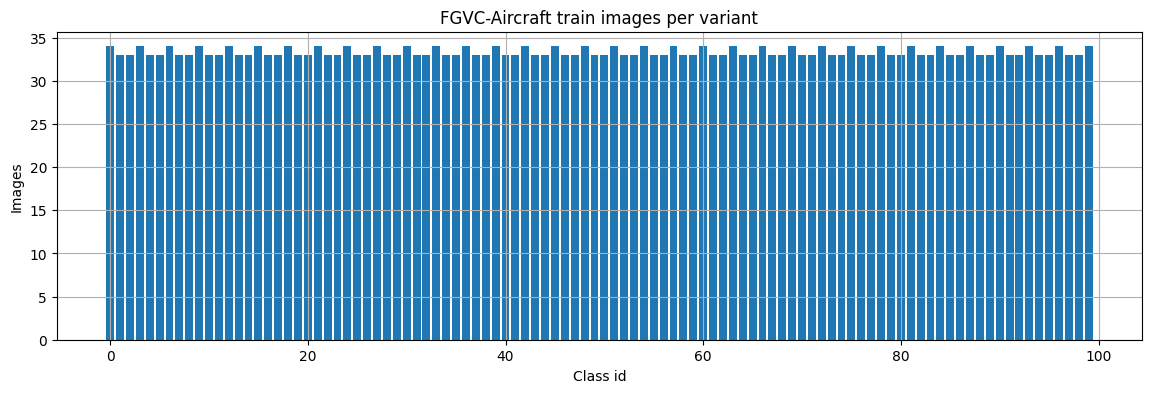

,class_id,class_name,count
0,0,707-320,34
3,3,737-300,34
9,9,737-900,34
6,6,737-600,34
30,30,A340-300,34
33,33,A380,34
15,15,757-300,34
12,12,747-300,34
18,18,767-400,34
27,27,A330-200,34


In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(np.arange(len(train_counts)), train_counts.sort_values("class_id")["count"])
ax.set_title("FGVC-Aircraft train images per variant")
ax.set_xlabel("Class id")
ax.set_ylabel("Images")
plt.show()

train_counts.head(10)

## Image Shape and Pixel Statistics

In [6]:
sample_size = min(512, len(train_ds))
indices = torch.randperm(len(train_ds))[:sample_size].tolist()
pixels = []
shapes = []

for idx in indices:
    image, _ = train_ds[idx]
    shapes.append(tuple(image.shape))
    pixels.append(image.reshape(3, -1))

pixel_tensor = torch.cat(pixels, dim=1)
pd.DataFrame({
    "channel": ["red", "green", "blue"],
    "mean": pixel_tensor.mean(dim=1).numpy(),
    "std": pixel_tensor.std(dim=1).numpy(),
}), Counter(shapes).most_common(5)

(  channel      mean       std
 0     red  0.480053  0.218660
 1   green  0.513218  0.209958
 2    blue  0.539660  0.243300,
 [((3, 224, 224), 512)])

## Example Images

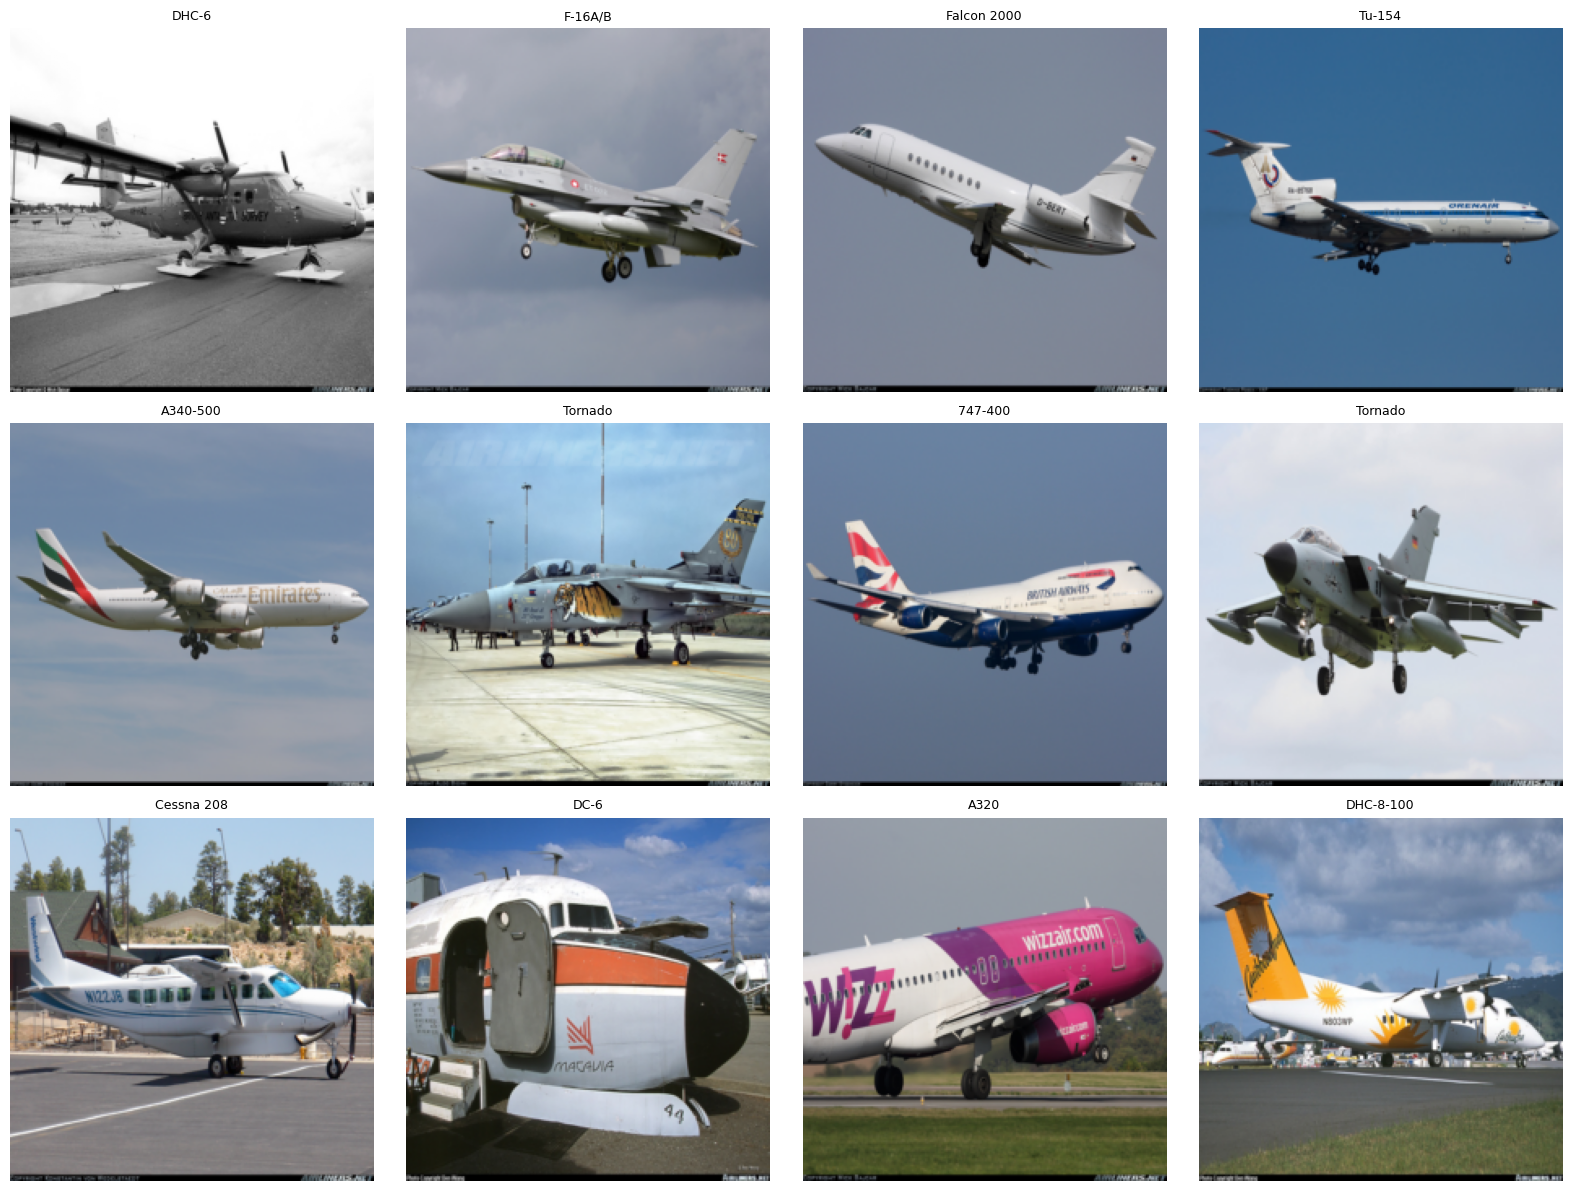

In [7]:
def show_examples(ds, n=12):
    indices = torch.randperm(len(ds))[:n].tolist()
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, indices):
        image, label = ds[idx]
        ax.imshow(image.permute(1, 2, 0).numpy())
        ax.set_title(ds.classes[label], fontsize=9)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()

show_examples(train_ds, n=12)

## Notes for the Distillation Project

- FGVC-Aircraft is fine-grained: many classes differ by subtle shape and part-level cues.
- The balanced split makes top-1 accuracy easy to compare across classes.
- Pre-GAP distillation may help because spatial structure can preserve aircraft shape and component details.